# Python libraries required

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing data

In [2]:
from tkinter import Tk, filedialog
import pandas as pd

root = Tk()
root.withdraw()

file_path = filedialog.askopenfilename(
    title="Select walmart.csv",
    filetypes=[("CSV files", "*.csv")]
)

print("Selected file:", file_path)

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(df.shape)

df.head()

Selected file: C:/Users/ajink/Downloads/kine trexa/walmart.csv.csv
Dataset loaded successfully!
(3203, 12)


,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,13-06-2013,17-06-2013,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,6.87
1,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,14.17
2,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.28,4.0,1.97
3,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.15,4.0,90.72
4,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3.0,5.78


In [3]:
import os
print(os.getcwd())

C:\Users\ajink


# Checking if data is loaded

In [4]:
df.head()
#df.tail()
#df.sample(n) format

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,13-06-2013,17-06-2013,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,6.87
1,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,14.17
2,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.28,4.0,1.97
3,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.15,4.0,90.72
4,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3.0,5.78


# Understanding the data

In [5]:
df.shape

(3203, 12)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       3203 non-null   str    
 1   Order Date     3203 non-null   str    
 2   Ship Date      3203 non-null   str    
 3   Customer Name  3203 non-null   str    
 4   Country        3203 non-null   str    
 5   City           3203 non-null   str    
 6   State          3203 non-null   str    
 7   Category       3203 non-null   str    
 8   Product Name   3203 non-null   str    
 9   Sales          3203 non-null   float64
 10  Quantity       3203 non-null   float64
 11  Profit         3203 non-null   float64
dtypes: float64(3), str(9)
memory usage: 683.5 KB


In [18]:
#df.describe() 
#numerical columns statistics summary include(mean,min,max,SD,quartiles)

# Data Cleaning & preprocessing
1. Handle Missing Values
2. Remove Duplicates
3. Fix Data types
4. Clean Text Data
5. Detect outliers
6. Standardize Column Names
7. Scale Numerical Data

# Handle Missing values

In [19]:


#Handle Missing Values
#Check Missing Values
# Check missing values
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Customer Name    0
Country          0
City             0
State            0
Category         0
Product Name     0
Sales            0
Quantity         0
Profit           0
dtype: int64

In [20]:
# Observation:
# No missing values were found in the dataset.
# Therefore, no missing value treatment was required.

#remove rows with missing values
#df = df.dropna()

#fill missing numeric values with the column mean/median/mode
#df["Sales"] = df["Sales"].fillna(df["Sales"].mean())
#df["Sales"] = df["Sales"].fillna(df["Sales"].median())
#df["Quantity"] = df["Quantity"].fillna(df["Quantity"].mode()[0])

# Remove Duplicates

In [21]:
# Check duplicate records
df.duplicated().sum()


np.int64(0)

In [22]:
# Observation:
# No dupliacte values were found in the dataset.
# Therefore, no duplicate value treatment was required.

#remove duplicates
#df = df.drop_duplicates()

#verify
#df.duplicated().sum()

# Fix the Data Types

In [23]:


#check current data types
df.dtypes

Order ID             str
Order Date           str
Ship Date            str
Customer Name        str
Country              str
City                 str
State                str
Category             str
Product Name         str
Sales            float64
Quantity         float64
Profit           float64
dtype: object

In [24]:
#Date Columns conversion
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [25]:
df.dtypes

Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Customer Name               str
Country                     str
City                        str
State                       str
Category                    str
Product Name                str
Sales                   float64
Quantity                float64
Profit                  float64
dtype: object

In [26]:


#observation
#Order Date and Ship Date have the datetime64[ns] data type

# check whether there any extra spaces in text columns

In [27]:
text_columns = df.select_dtypes(include=["object", "string"]).columns
for col in text_columns:
    print(f"{col}:",
          (df[col] != df[col].str.strip()).sum(),)
#Before cleaning text,can check whether there are any extra spaces

Order ID: 0
Customer Name: 0
Country: 0
City: 0
State: 0
Category: 0
Product Name: 2


# Clean Text Data

In [28]:
## Observation:
# Extra spaces in text column i.e. Product Name were found in the dataset.
# Therefore, clean text data treatment required.
text_columns = [
    "Order ID",
    "Customer Name",
    "Country",
    "City",
    "State",
    "Category",
    "Product Name"
]

for col in text_columns:
    df[col] = df[col].str.strip()
# Standardize text formatting for consistency
#df["Country"] = df["Country"].str.title()
#df["City"] = df["City"].str.title()
#df["State"] = df["State"].str.title()
#df["Category"] = df["Category"].str.title()
#df["Product Name"] = df["Product Name"].str.title()


# Detect Outliers

In [29]:
# Display numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

print("Numerical Columns:", numerical_cols)

Numerical Columns: ['Sales', 'Quantity', 'Profit']


In [30]:
Q1 = df.quantile(numeric_only=True, q=0.25)
Q3 = df.quantile(numeric_only=True, q=0.75)

IQR = Q3 - Q1

outliers = df[
    ((df[Q1.index] < (Q1 - 1.5 * IQR)) |
     (df[Q1.index] > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("Number of Outlier Rows:", len(outliers))
#outliers

Number of Outlier Rows: 626


Number of Outliers for Sales: 368
Lowest Outlier of Sales: 511.06
Highest Outlier of Sales: 13999.96


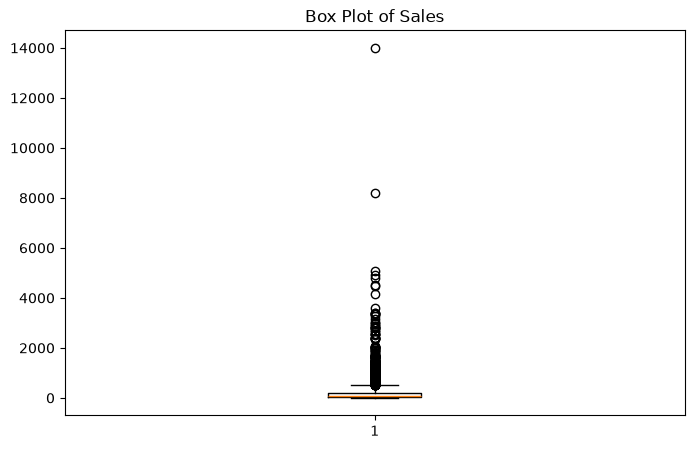

In [31]:
#for a sales dataset: sales,quantity,profit detecting outliers is important but removing them is not ideal. 
#Because high sales and profits are often real business transactions, not errors.

# Detect outliers in Sales using IQR
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["Sales"] < lower_limit) | (df["Sales"] > upper_limit)]

print("Number of Outliers for Sales:", len(outliers))
print("Lowest Outlier of Sales:", outliers["Sales"].min())
print("Highest Outlier of Sales:", outliers["Sales"].max())
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df["Sales"])
plt.title("Box Plot of Sales")
plt.show()


Total Profit Outliers: 465
Lowest Profit Outlier: -3399.98
Highest Profit Outlier: 6719.98


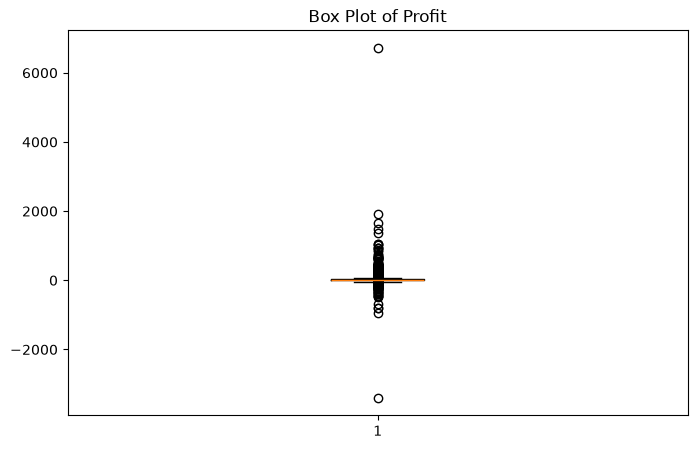

In [32]:
#Detect outliers in profit using IQR
Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["Profit"] < lower_limit) | (df["Profit"] > upper_limit)]
print("Total Profit Outliers:", len(outliers))
print("Lowest Profit Outlier:", outliers["Profit"].min())
print("Highest Profit Outlier:", outliers["Profit"].max())
plt.figure(figsize=(8,5))
plt.boxplot(df["Profit"])
plt.title("Box Plot of Profit")
plt.show()

Total Quantity Outliers: 62
Lowest Quantity Outlier: 10.0
Highest Quantity Outlier: 14.0


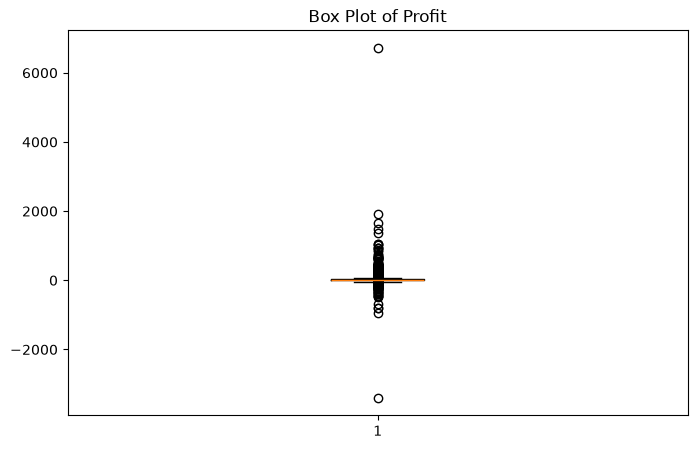

In [33]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["Quantity"] < lower_limit) | (df["Quantity"] > upper_limit)]
print("Total Quantity Outliers:", len(outliers))
print("Lowest Quantity Outlier:", outliers["Quantity"].min())
print("Highest Quantity Outlier:", outliers["Quantity"].max())
plt.figure(figsize=(8,5))
plt.boxplot(df["Profit"])
plt.title("Box Plot of Profit")
plt.show()

# Standardize Column Names

In [34]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
#df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Customer_Name', 'Country',
       'City', 'State', 'Category', 'Product_Name', 'Sales', 'Quantity',
       'Profit'],
      dtype='str')

# Scale numerical data

In [35]:
"""from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["Sales", "Profit", "Quantity"]] = scaler.fit_transform(
    df[["Sales", "Profit", "Quantity"]]
)"""
#scaling numerical data is not ideal for data analysis unlike model building

'from sklearn.preprocessing import MinMaxScaler\n\nscaler = MinMaxScaler()\n\ndf[["Sales", "Profit", "Quantity"]] = scaler.fit_transform(\n    df[["Sales", "Profit", "Quantity"]]\n)'

In [36]:
#save cleaned dataset
df.to_csv("walmart_cleaned.csv", index=False)

In [37]:
#load cleaned dataset
df = pd.read_csv("walmart_cleaned.csv")

In [38]:
df.dtypes
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"])
df.dtypes

Order_ID                    str
Order_Date       datetime64[us]
Ship_Date        datetime64[us]
Customer_Name               str
Country                     str
City                        str
State                       str
Category                    str
Product_Name                str
Sales                   float64
Quantity                float64
Profit                  float64
dtype: object

# EDA(Exploratory data analysis)
Understanding data for building model/dashboard. Mainly includes:
1. Dataset Overview
2. Statistical Summary
3. Category-wise Sales
4. State-wise Sales
5. Top 10 Products
6. Top Customers
7. Monthly Sales Trend
8. Correlation (Sales, Profit, Quantity)


# Dataset Overview

In [39]:
df.head()


,Order_ID,Order_Date,Ship_Date,Customer_Name,Country,City,State,Category,Product_Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,6.87
1,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,14.17
2,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.28,4.0,1.97
3,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.15,4.0,90.72
4,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3.0,5.78


In [40]:
df.tail()

,Order_ID,Order_Date,Ship_Date,Customer_Name,Country,City,State,Category,Product_Name,Sales,Quantity,Profit
3198,CA-2013-125794,2013-09-30,2013-10-04,Maris LaWare,United States,Los Angeles,California,Accessories,Memorex Mini Travel Drive 64 GB USB 2.0 Flash ...,36.24,1.0,15.22
3199,CA-2014-121258,2014-02-27,2014-03-04,Dave Brooks,United States,Costa Mesa,California,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.96,2.0,15.63
3200,CA-2014-121258,2014-02-27,2014-03-04,Dave Brooks,United States,Costa Mesa,California,Phones,Aastra 57i VoIP phone,258.58,2.0,19.39
3201,CA-2014-121258,2014-02-27,2014-03-04,Dave Brooks,United States,Costa Mesa,California,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.60,4.0,13.32
3202,CA-2014-119914,2014-05-05,2014-05-10,Chris Cortes,United States,Westminster,California,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.16,2.0,72.95


In [41]:
df.shape

(3203, 12)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       3203 non-null   str           
 1   Order_Date     3203 non-null   datetime64[us]
 2   Ship_Date      3203 non-null   datetime64[us]
 3   Customer_Name  3203 non-null   str           
 4   Country        3203 non-null   str           
 5   City           3203 non-null   str           
 6   State          3203 non-null   str           
 7   Category       3203 non-null   str           
 8   Product_Name   3203 non-null   str           
 9   Sales          3203 non-null   float64       
 10  Quantity       3203 non-null   float64       
 11  Profit         3203 non-null   float64       
dtypes: datetime64[us](2), float64(3), str(7)
memory usage: 621.0 KB


In [43]:
df.describe()

,Order_Date,Ship_Date,Sales,Quantity,Profit
count,3203,3203,3203.000000,3203.000000,3203.000000
mean,2013-05-10 03:06:07.530440,2013-05-14 01:25:25.195129,226.493266,3.828910,33.849138
min,2011-01-07 00:00:00,2011-01-09 00:00:00,0.990000,1.000000,-3399.980000
25%,2012-05-22 00:00:00,2012-05-26 00:00:00,19.440000,2.000000,3.850000
50%,2013-07-22 00:00:00,2013-07-25 00:00:00,60.840000,3.000000,11.170000
75%,2014-05-23 00:00:00,2014-05-27 00:00:00,215.810000,5.000000,33.000000
max,2014-12-31 00:00:00,2015-01-06 00:00:00,13999.960000,14.000000,6719.980000
std,NaN,NaN,524.876911,2.260947,174.109155


# Statistical Summary

In [44]:
numerical_cols = df.select_dtypes(include='number').columns

print(numerical_cols)
df[numerical_cols].describe()

Index(['Sales', 'Quantity', 'Profit'], dtype='str')


,Sales,Quantity,Profit
count,3203.000000,3203.000000,3203.000000
mean,226.493266,3.828910,33.849138
std,524.876911,2.260947,174.109155
min,0.990000,1.000000,-3399.980000
25%,19.440000,2.000000,3.850000
50%,60.840000,3.000000,11.170000
75%,215.810000,5.000000,33.000000
max,13999.960000,14.000000,6719.980000


# category-wise sales

In [45]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales.apply(lambda x: f"{x:,.2f}"))
#17 unique categories of products are present

Category
Chairs         101,781.36
Phones          98,684.39
Tables          84,754.60
Storage         70,532.84
Accessories     61,114.10
Binders         55,961.11
Copiers         49,749.23
Machines        42,444.14
Bookcases       36,004.18
Appliances      30,236.32
Furnishings     30,072.73
Paper           26,663.73
Supplies        18,127.12
Art              9,212.06
Labels           5,078.72
Envelopes        4,118.10
Fasteners          923.20
Name: Sales, dtype: str


In [46]:
"""pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
summary = df.groupby("Category").agg(
    Product_Count=("Product_Name", "nunique"),
    Product_Names=("Product_Name", lambda x: ", ".join(sorted(x.unique())))
)

summary"""
#this code snippet represents the what unique categories are present in dataset
#and also count of how many unique products i.e. unique product names does each category contains along with the product names

'pd.set_option(\'display.max_colwidth\', None)\npd.set_option(\'display.max_rows\', None)\nsummary = df.groupby("Category").agg(\n    Product_Count=("Product_Name", "nunique"),\n    Product_Names=("Product_Name", lambda x: ", ".join(sorted(x.unique())))\n)\n\nsummary'

In [47]:
"""for category in sorted(df["Category"].unique()):

    category_df = df[df["Category"] == category]

    unique_products = category_df["Product_Name"].nunique()

    print("\n" + "="*80)
    print(f"Category: {category}")
    print(f"Unique Products: {unique_products}")
    print("-"*80)

    product_counts = category_df["Product_Name"].value_counts()

    for product, count in product_counts.items():
        print(f"{product} : {count}")"""
#this code snippet represents,category: category name-> Unique products: Count-> Unique product name: quantiy count

'for category in sorted(df["Category"].unique()):\n\n    category_df = df[df["Category"] == category]\n\n    unique_products = category_df["Product_Name"].nunique()\n\n    print("\n" + "="*80)\n    print(f"Category: {category}")\n    print(f"Unique Products: {unique_products}")\n    print("-"*80)\n\n    product_counts = category_df["Product_Name"].value_counts()\n\n    for product, count in product_counts.items():\n        print(f"{product} : {count}")'

In [48]:
# Product-wise Sales and Quantity
product_summary = (
    df.groupby(["Category", "Product_Name"])
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
      .reset_index()
)

# Highest-selling product
highest_sales = product_summary.loc[product_summary["Total_Sales"].idxmax()]

# Lowest-selling product
lowest_sales = product_summary.loc[product_summary["Total_Sales"].idxmin()]

print("Highest Selling Product")
print("-----------------------")
print("Category       :", highest_sales["Category"])
print("Product        :", highest_sales["Product_Name"])
print("Total Sales    :", f"{highest_sales['Total_Sales']:,.2f}")

print("\nLowest Selling Product")
print("----------------------")
print("Category       :", lowest_sales["Category"])
print("Product        :", lowest_sales["Product_Name"])
print("Total Sales    :", f"{lowest_sales['Total_Sales']:,.2f}")

Highest Selling Product
-----------------------
Category       : Copiers
Product        : Canon imageCLASS 2200 Advanced Copier
Total Sales    : 13,999.96

Lowest Selling Product
----------------------
Category       : Fasteners
Product        : Colored Push Pins
Total Sales    : 1.81


# State-wise sales


In [49]:
print("Total States:", df["State"].nunique())

Total States: 11


In [50]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
print(state_sales.apply(lambda x: f"{x:,.2f}"))

State
California    457,687.68
Washington    138,641.29
Arizona        35,282.02
Colorado       32,108.12
Oregon         17,431.14
Nevada         16,729.10
Utah           11,220.06
Montana         5,589.35
New Mexico      4,783.54
Idaho           4,382.49
Wyoming         1,603.14
Name: Sales, dtype: str


### Observation

- Among all states, California generated the highest sales revenue, indicating strong market performance.
- Wyoming recorded the lowest sales contribution, suggesting limited customer activity compared to other regions.
- Regional sales differences highlight opportunities for targeted marketing strategies and business expansion.

# Top 10 Products by sales

In [51]:
# Top 10 Products by Sales
top10_products = (
    df.groupby("Product_Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top10_products.apply(lambda x: f"{x:,.2f}"))
#observations
#The below data lists the Top 10 products based on total sales.
#Top 1 product with highest sales is Canon imageCLASS 2200 Advanced Copier 
#Top 10 product with high sales is Hewlett Packard LaserJet 3310 Copier 


Product_Name
Canon imageCLASS 2200 Advanced Copier                                          13,999.96
High Speed Automatic Electric Letter Opener                                    13,100.24
Global Troy Executive Leather Low-Back Tilter                                  10,019.61
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     8,134.33
GuestStacker Chair with Chrome Finish Legs                                      8,030.01
Okidata MB760 Printer                                                           7,834.40
Bretford Rectangular Conference Table Tops                                      7,710.66
Logitech P710e Mobile Speakerphone                                              7,467.21
Canon PC1060 Personal Laser Copier                                              6,719.90
Hewlett Packard LaserJet 3310 Copier                                            6,239.89
Name: Sales, dtype: str


# Top 10 Customers by Sales

In [52]:
# Top 10 Customers by Sales
top_customers = (
    df.groupby("Customer_Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers.apply(lambda x: f"{x:,.2f}"))
#observation
#top 1 to top 10 customers by sales

Customer_Name
Raymond Buch      14,345.28
Ken Lonsdale       8,472.39
Edward Hooks       7,447.77
Jane Waco          7,391.53
Karen Ferguson     7,182.76
Nick Crebassa      6,734.23
Clay Ludtke        6,069.65
Yana Sorensen      5,754.17
Nora Preis         5,564.60
William Brown      5,523.06
Name: Sales, dtype: str


In [53]:
print("Total Unique Customers:", df["Customer_Name"].nunique())

Total Unique Customers: 686


# Monthly Sales Trend

In [54]:
# Create Month-Year column
df["Month_Year"] = df["Order_Date"].dt.to_period("M")

In [55]:
# Monthly Sales Trend
monthly_sales = (
    df.groupby("Month_Year")["Sales"]
      .sum()
)

print(monthly_sales.apply(lambda x: f"{x:,.2f}"))

Month_Year
2011-01     2,648.05
2011-02     1,348.64
2011-03    11,008.91
2011-04     9,343.49
2011-05     6,570.44
2011-06     9,629.41
2011-07    21,808.55
2011-08    13,248.24
2011-09    14,900.55
2011-10     8,728.75
2011-11    23,191.63
2011-12    25,456.41
2012-01     6,026.74
2012-02     2,004.90
2012-03    15,461.42
2012-04     9,056.03
2012-05    12,042.67
2012-06     5,088.96
2012-07     7,089.84
2012-08    12,548.35
2012-09    13,898.91
2012-10    14,016.66
2012-11    14,548.89
2012-12    28,182.87
2013-01     3,657.83
2013-02     3,100.17
2013-03    17,559.00
2013-04    10,370.14
2013-05    10,806.15
2013-06    18,598.09
2013-07    14,417.78
2013-08    12,680.97
2013-09    23,620.90
2013-10    13,135.38
2013-11    26,412.33
2013-12    32,617.35
2014-01    12,586.01
2014-02     9,814.93
2014-03    28,994.40
2014-04    13,196.93
2014-05    15,901.63
2014-06    15,203.08
2014-07    21,390.78
2014-08    24,196.76
2014-09    29,198.10
2014-10    21,556.00
2014-11    28,915.96
20

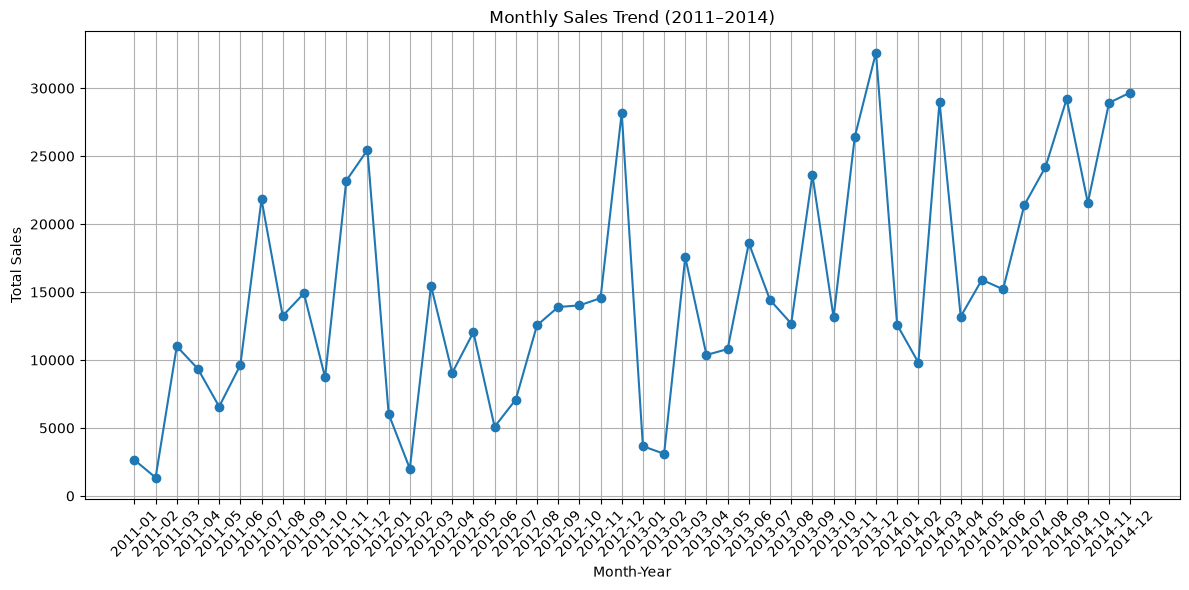

In [56]:
import matplotlib.pyplot as plt

# Monthly Sales Trend
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index.astype(str),
         monthly_sales.values,
         marker='o')

plt.title("Monthly Sales Trend (2011–2014)")
plt.xlabel("Month-Year")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()
plt.show()

In [57]:
print("Highest Sales Month")
print("-------------------")
print("Month       :", monthly_sales.idxmax())
print("Total Sales :", f"{monthly_sales.max():,.2f}")

print("\nLowest Sales Month")
print("------------------")
print("Month       :", monthly_sales.idxmin())
print("Total Sales :", f"{monthly_sales.min():,.2f}")

Highest Sales Month
-------------------
Month       : 2013-12
Total Sales : 32,617.35

Lowest Sales Month
------------------
Month       : 2011-02
Total Sales : 1,348.64


# Correlation (Sales, Profit, Quantity)

In [58]:
#correlation matrix
correlation = df[["Sales", "Profit", "Quantity"]].corr()

print(correlation)

             Sales    Profit  Quantity
Sales     1.000000  0.647477  0.214665
Profit    0.647477  1.000000  0.093240
Quantity  0.214665  0.093240  1.000000


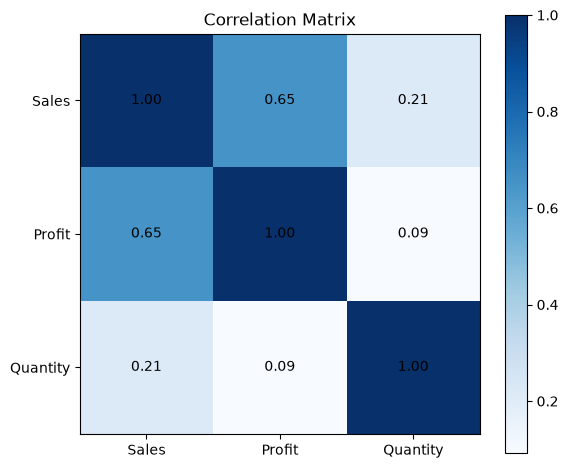

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(correlation, cmap="Blues", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)

# Display correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i,
                 f"{correlation.iloc[i, j]:.2f}",
                 ha="center",
                 va="center",
                 color="black")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Interpretation Guide
| Correlation Value | Interpretation |
|-------------------|----------------|
| +1.00 | Perfect Positive Correlation |
| 0.70 to 0.99 | Strong Positive Correlation |
| 0.30 to 0.69 | Moderate Positive Correlation |
| 0.01 to 0.29 | Weak Positive Correlation |
| 0.00 | No Correlation |
| Negative Values | Negative (Inverse) Correlation |

# Observations

•  Sales and Profit have a correlation of 0.48, indicating a moderate positive relationship.  
•  Sales and Quantity have a correlation of 0.21, indicating a weak positive relationship.  
•  Profit and Quantity have a correlation of 0.05, indicating a very weak positive relationship.  
•  Sales generally increase with Profit, but the relationship is not very strong.  
•  Correlation indicates association between variables and does not imply causation.  

# KPI Analysis

Key Performance Indicators (KPIs) help measure overall business performance.

The following metrics are calculated:
- Total Sales Revenue
- Total Orders
- Total Customers
- Total Quantity Sold
- Total Profit
- Average Order Value
- Profit Margin

In [60]:
# KPI Calculations

total_sales = df['Sales'].sum()

total_orders = df['Order_ID'].nunique()

total_customers = df['Customer_Name'].nunique()

total_quantity = df['Quantity'].sum()

total_profit = df['Profit'].sum()

average_order_value = total_sales / total_orders

profit_margin = (total_profit / total_sales) * 100


print("Total Sales:", round(total_sales,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Quantity Sold:", int(total_quantity))
print("Total Profit:", round(total_profit,2))
print("Average Order Value:", round(average_order_value,2))
print("Profit Margin:", round(profit_margin,2),"%")

Total Sales: 725457.93
Total Orders: 1611
Total Customers: 686
Total Quantity Sold: 12264
Total Profit: 108418.79
Average Order Value: 450.32
Profit Margin: 14.94 %


## Business Insights from KPI Analysis

- The business generated a total revenue of **$725,457.93** from **1,611 unique orders**, indicating strong sales performance during the analyzed period.

- The company served **686 unique customers**, showing a diverse customer base and consistent customer engagement.

- A total of **12,264 products were sold**, which indicates healthy product demand and effective sales operations.

- The average order value (AOV) is **$450.32**, suggesting that customers are making relatively high-value purchases per transaction.

- The business achieved a total profit of **$108,418.79**, resulting in a profit margin of **14.94%**, indicating that the company maintains a positive profitability level.

- Although sales volume is strong, improving the profit margin further through better pricing strategies, cost optimization, and focusing on high-margin products can increase overall profitability.

- Customer retention strategies, personalized marketing, and targeted promotions can help increase repeat purchases and improve long-term revenue growth.